In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

warnings.filterwarnings('ignore')

In [169]:
df = pd.read_csv("insurance.csv")

In [170]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [171]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [172]:
df.shape

(1338, 7)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [174]:
# smoker, sex, region, 

In [175]:
df['smoker'] = df['smoker'].astype('string')

In [176]:
df['sex'] = df['sex'].astype('string')

In [177]:
df['region'] = df['region'].astype('string')

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   string 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   string 
 5   region    1338 non-null   string 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), string(3)
memory usage: 73.3 KB


In [179]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [180]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [181]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

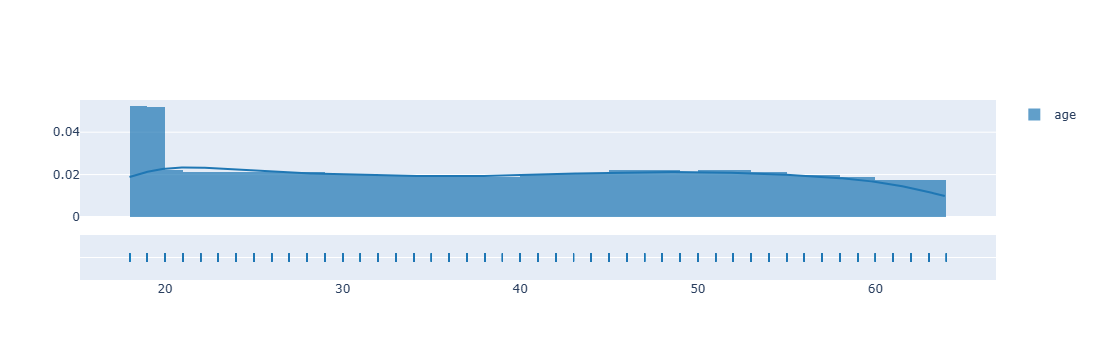

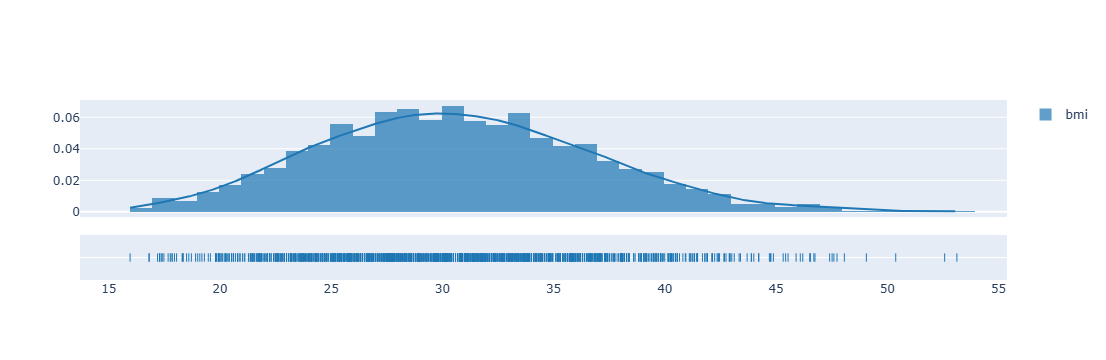

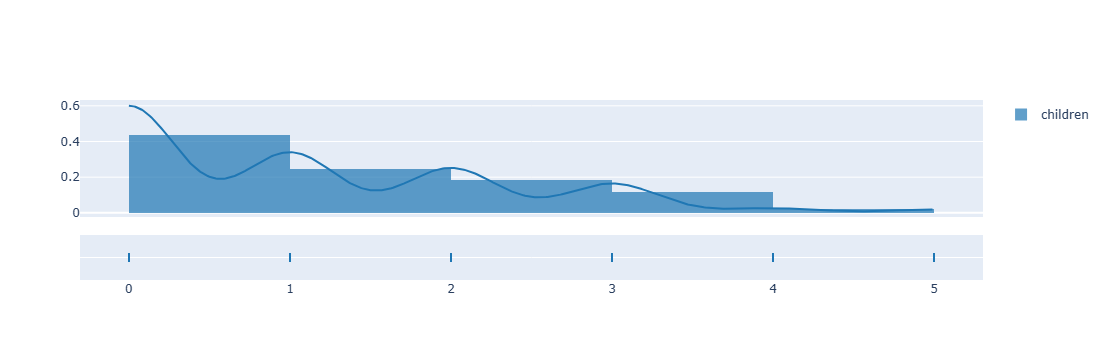

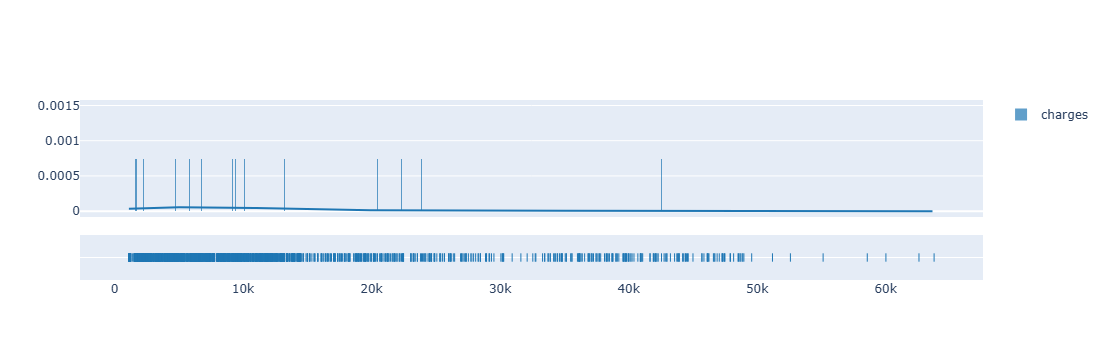

In [182]:
numeric_columns = ['age', 'bmi', 'children', 'charges']

for col in numeric_columns:
    data = df[col]
    fig = ff.create_distplot([data], [col])
    fig.show()

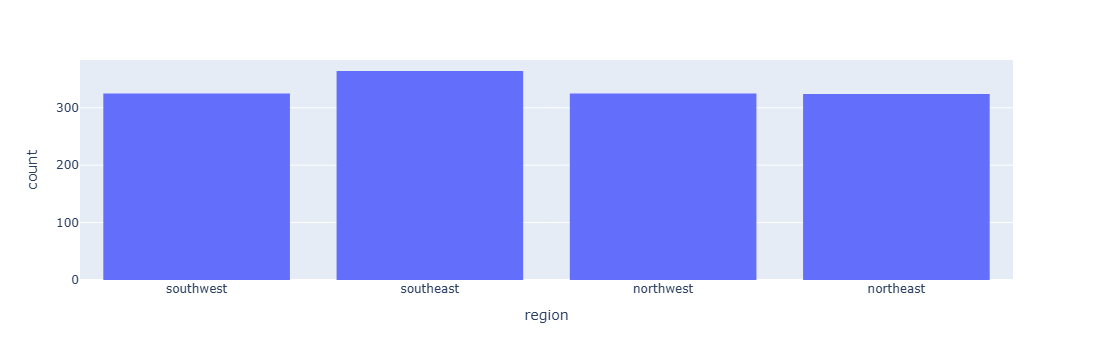

In [183]:
px.histogram(df, x='region')

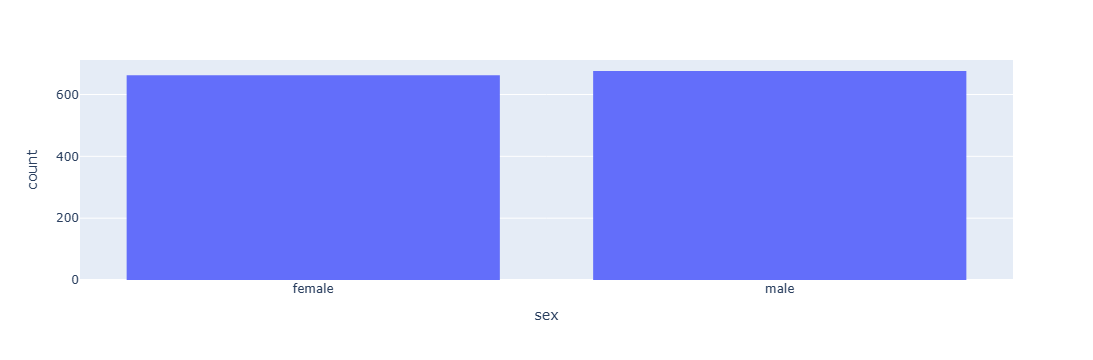

In [184]:
px.histogram(df, x='sex')

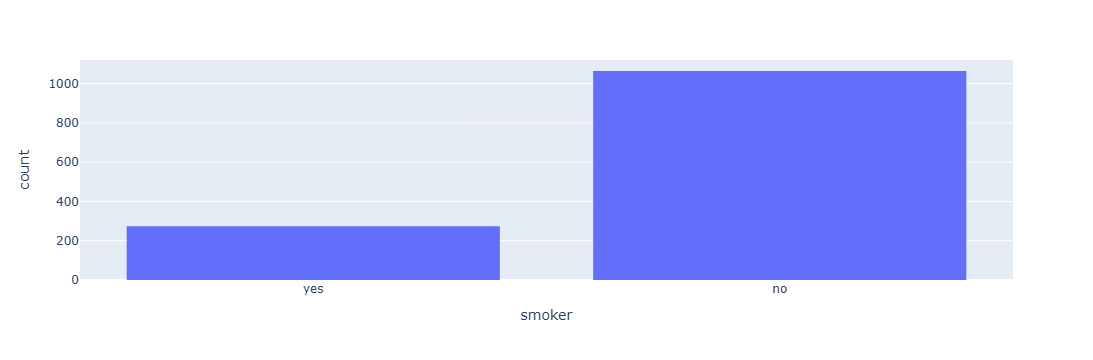

In [185]:
px.histogram(df, x = 'smoker')

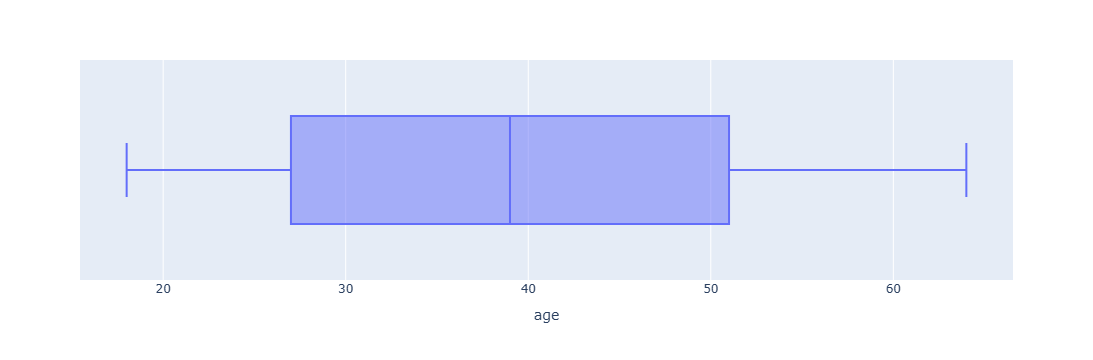

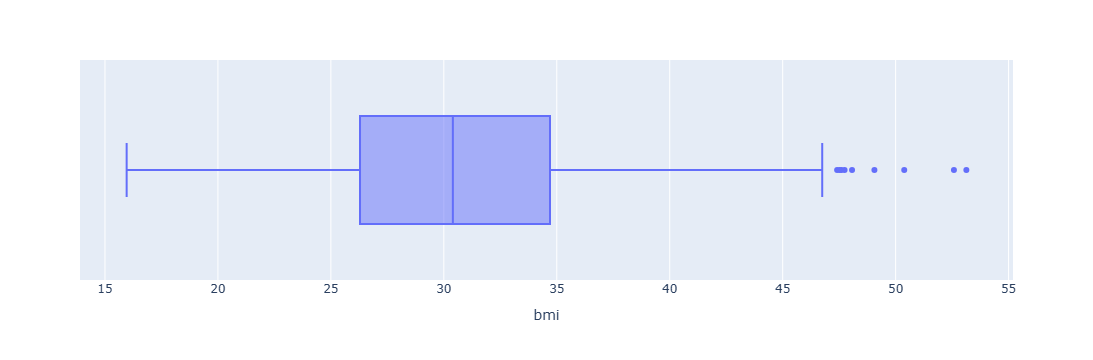

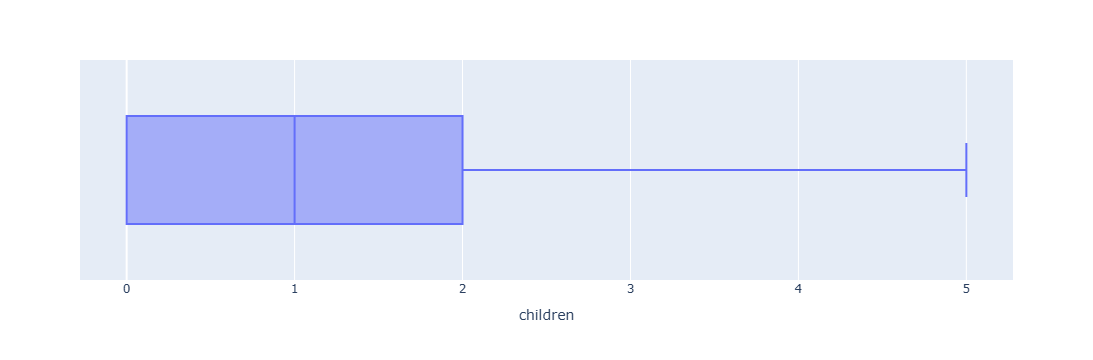

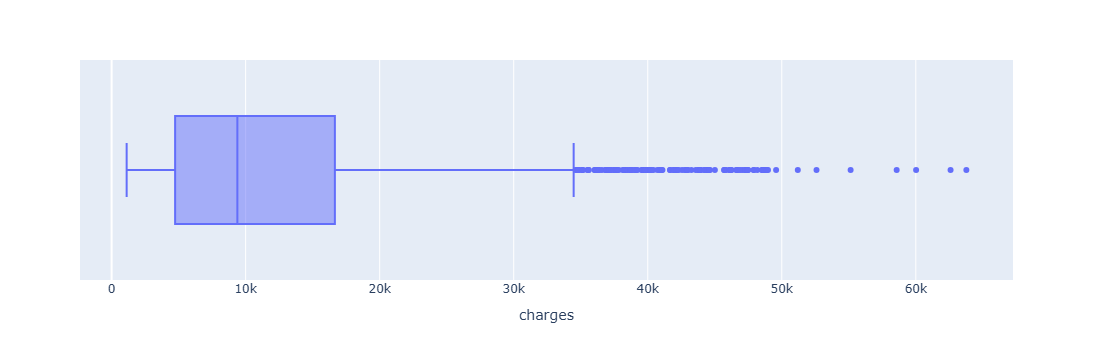

In [186]:
numeric_columns
for col in numeric_columns:
    fig = px.box(df, x=col)
    fig.show()

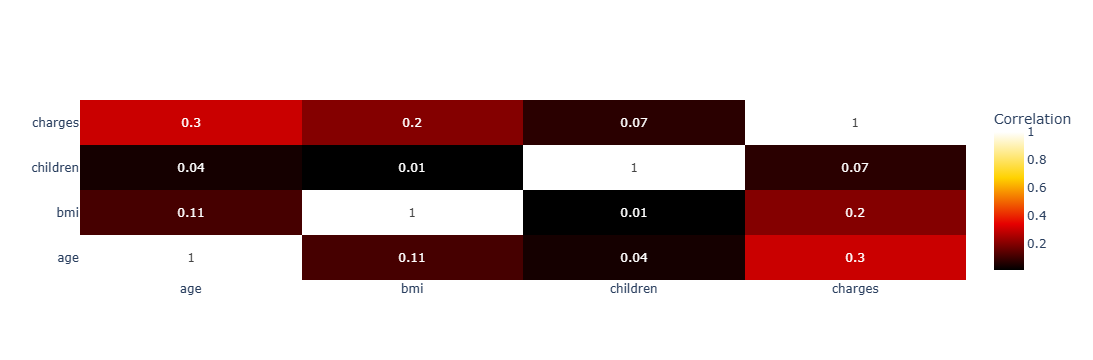

In [187]:
# fig = px.density_heatmap(df, x=numeric_columns, y=numeric_columns)
# fig.show()

corr = df[numeric_columns].corr().round(2)

go.Figure(
    go.Heatmap(
        x=corr.columns,
        y=corr.index,
        z=corr.values,
        colorscale='Hot',
        colorbar=dict(title="Correlation"),
        texttemplate= "%{z}"
    )
)

# Blackbody,Bluered,Blues,Cividis,Earth,Electric,Greens,Greys,Hot,Jet,Picnic,Portland,Rainbow,RdBu,Reds,Viridis,YlGnBu,YlOrRd

## Data Cleaning and Pre-Processing

In [188]:
df_cleaned = df.copy()

In [189]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [190]:
df_cleaned.shape

(1338, 7)

In [191]:
df_cleaned.drop_duplicates(inplace=True)

In [192]:
df_cleaned.shape

(1337, 7)

In [193]:
df_cleaned.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [194]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: Int64

In [195]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male": 0, "female": 1})

In [196]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [197]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: Int64

In [198]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0, 'yes': 1})

In [199]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [200]:
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

In [201]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [202]:
df_cleaned['region'] = df_cleaned['region'].astype('str')
df_cleaned.dtypes

age            int64
is_female      int64
bmi          float64
children       int64
is_smoker      int64
region        object
charges      float64
dtype: object

In [203]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [204]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [205]:
df_cleaned = df_cleaned.astype(int)

In [206]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [207]:
df_cleaned.shape

(1337, 9)

# Feature Engineering and Extraction

In [208]:
df_cleaned['bmi_category'] = pd.cut(
    df['bmi'],
    bins = [0, 18.5, 24.9, 29.9, float("inf")],
    labels = ['underweight', 'healthy', 'overweight', 'obesity']

)

In [209]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obesity
2,28,0,33,3,0,4449,0,1,0,obesity
3,33,0,22,0,0,21984,1,0,0,healthy
4,32,0,28,0,0,3866,1,0,0,overweight


In [210]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [211]:
df_cleaned = df_cleaned.astype(int)

In [212]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_healthy,bmi_category_overweight,bmi_category_obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [213]:
from sklearn.preprocessing import StandardScaler

In [214]:
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [215]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_healthy,bmi_category_overweight,bmi_category_obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [216]:
from scipy.stats import pearsonr

In [217]:
selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_healthy', 'bmi_category_overweight',
       'bmi_category_obesity']

correlation = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

In [218]:
correlation

{'age': np.float64(0.29830870258771747),
 'is_female': np.float64(-0.05804580933726396),
 'bmi': np.float64(0.1962362929936443),
 'children': np.float64(0.0673902418591206),
 'is_smoker': np.float64(0.7872337542693595),
 'region_northwest': np.float64(-0.038695151612761325),
 'region_southeast': np.float64(0.07357719339126036),
 'region_southwest': np.float64(-0.04363698192991321),
 'bmi_category_healthy': np.float64(-0.10565555074698472),
 'bmi_category_overweight': np.float64(-0.11827998921647315),
 'bmi_category_obesity': np.float64(0.1976603284886533)}

In [219]:
corr_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Pearson_correlation'])
corr_df.sort_values(by='Pearson_correlation', ascending=False)

,Feature,Pearson_correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obesity,0.197660
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_healthy,-0.105656


In [220]:
cat_features = ['is_smoker', 'bmi_category_obesity', 'region_southeast', 'region_northwest', 'region_southwest', 'is_female', 'bmi_category_overweight', 'bmi_category_healthy']

In [221]:
from scipy.stats import chi2_contingency
import pandas as pd

In [222]:
alpha = 0.5

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = "Reject null hypothesis (Keep feature)" if p_val < alpha else "Accept null hypothesis (Drop feature)"
    chi2_results[col] = {
        'chi2_statistics' : chi2_stat,
        'p_value': p_val,
        'decision' : decision
    }

In [223]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistics,p_value,decision
is_smoker,848.219178,0.0,Reject null hypothesis (Keep feature)
region_southeast,15.998167,0.001135,Reject null hypothesis (Keep feature)
is_female,10.258784,0.01649,Reject null hypothesis (Keep feature)
bmi_category_obesity,7.654464,0.05372,Reject null hypothesis (Keep feature)
region_southwest,5.091893,0.165191,Reject null hypothesis (Keep feature)
bmi_category_healthy,4.263673,0.234364,Reject null hypothesis (Keep feature)
bmi_category_overweight,4.201575,0.240504,Reject null hypothesis (Keep feature)
region_northwest,1.13424,0.768815,Accept null hypothesis (Drop feature)


In [224]:
final_df = df_cleaned.drop('region_northwest', axis=1)

In [225]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,region_southwest,bmi_category_healthy,bmi_category_overweight,bmi_category_obesity,charges_bin
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,1,0,1,0,3
1,-1.511647,0,0.462463,-0.079442,0,1725,1,0,0,0,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,1,0,0,0,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0,1,0,0,3
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,0,0,0,1,2
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,1,0
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,0,0,0,1,0
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,1,0,1,0,0


In [226]:
from sklearn.model_selection import train_test_split

In [227]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

In [228]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [229]:
from sklearn.linear_model import LinearRegression

In [230]:
model = LinearRegression()

In [231]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [232]:
y_pred = model.predict(X_test)

In [233]:
from sklearn.metrics import r2_score

In [234]:
r2 = r2_score(y_test, y_pred)
r2

0.8285746586112325

In [237]:
n = X_test.shape[0]
p = X_test.shape[1]
X_test.shape

(268, 11)

In [241]:
adjusted_r2 = ((1 - r2) * (n - 1) / (n - p - 1))
adjusted_r2

0.17879127402656614